## **Portfolio Visualizer**
---

In [1]:
import math
import numpy as np
import pandas as pd
from pylab import plt
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('seaborn-v0_8-colorblind') 
np.set_printoptions(suppress = True)
%config InlineBackend.figure_format = 'svg'

#### **1. Load Data Files**

In [2]:
data1 = pd.read_csv('aspect_partners.csv', index_col = 0, parse_dates = True)
data2 = pd.read_csv('SPY_Long_Vol.csv', index_col = 0, parse_dates = True)
data3 = pd.read_csv('SPY_Long_Bond.csv', index_col = 0, parse_dates = True)
data4 = pd.read_csv('State_Street_ETF.csv', index_col = 0, parse_dates = True)

#### **2. Returns**

In [3]:
portfolio = [data1, data2, data3, data4]
returns_port = [data.pct_change().dropna() for data in portfolio]

#### **3. Annualized Covariance Matrix and Individual Asset Volatilities**

In [4]:
# td <- trading days (252)
def annual_cov(returns, td):
    covar_matrix = returns.cov()*td
    return covar_matrix
def annual_vol(returns, td):
    volatilities = returns.std()*np.sqrt(td)
    return volatilities 

In [5]:
covar_matrices = [annual_cov(returns, td = 252) for returns in returns_port]
vol_annual = [annual_vol(returns, td = 252) for returns in returns_port]

#### **4. Backtest Results**

In [7]:
from walk_fwd_btest import *
divs_paths = ['divs_aspect_partners.csv', 'divs_SPY_Long_Vol.csv', 
              'divs_SPY_Long_Bond.csv', 'divs_State_Street_ETF.csv']
results_backtest = []
for retns, prcs, divs in zip(returns_port, portfolio, divs_paths):
    results = walk_forward_backtest(
        returns = retns, 
        rebalance_frequency = 'quarterly', 
        lookback_months = 1, 
        prices = prcs,
        div_csv_path = divs
        )
    results_backtest.append(results)
    #print(results_backtest)

In [8]:
from functools import reduce
# 1. Create a list of the backtest_results DataFrames
dfs = [df.loc[:, ['date', 'portfolio_value']] for df in results_backtest]

for i, df in enumerate(dfs):
    df.rename(columns = {'portfolio_value': f'portfolio_value_df{i+1}' 
                         for col in df.columns if col != 'date'}, inplace=True)
portfolio_value = reduce(lambda x, y: pd.merge(x, y, on = 'date', how = 'outer'), dfs)
data = []
data.insert(0, {'date': '2024-01-01', 'portfolio_value_df1': 10000, 
                'portfolio_value_df2': 10000, 
                'portfolio_value_df3': 10000, 
                'portfolio_value_df4': 10000
               })
portfolio_value_ = pd.concat([pd.DataFrame(data), portfolio_value], ignore_index = True)
portfolio_value_['date'] = pd.to_datetime(portfolio_value_['date'], format = "%Y-%m-%d")

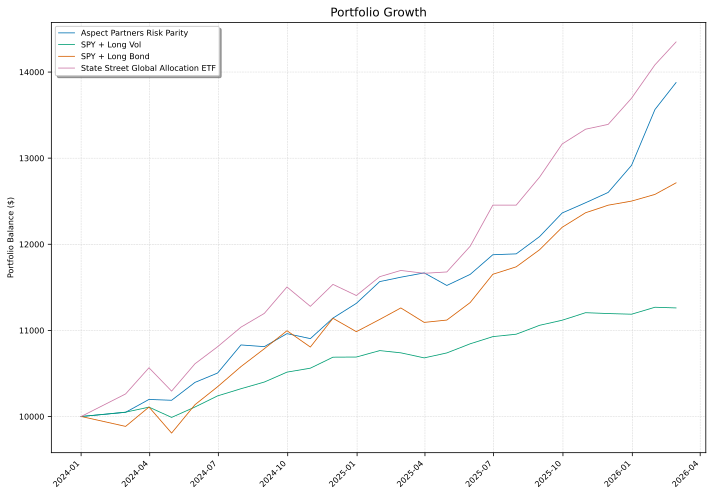

In [9]:
plt.style.use('seaborn-v0_8-colorblind')
y = portfolio_value_.columns.tolist()[1:]
portfolio_names = ['Aspect Partners Risk Parity', 'SPY + Long Vol', 
                   'SPY + Long Bond', 'State Street Global Allocation ETF']
plt.figure(figsize = (10, 7))
plt.plot(portfolio_value_['date'], portfolio_value_[y], linewidth = .8)
plt.ylabel('Portfolio Balance ($)', fontsize = 8)
plt.yticks(fontsize = 8)
plt.xticks(rotation = 45, ha = 'right', fontsize = 8)
plt.grid(True,
        linestyle='--',  
        linewidth=0.5,    
        color='lightgray') 
plt.title('Portfolio Growth')
plt.legend(portfolio_names, loc = 'upper left', 
           frameon = True, shadow = True, 
           fontsize = 8)
plt.tight_layout()            
plt.show();

In [14]:
#%load_ext autoreload
#%autoreload 2

#### **5. Annual Returns**

In [10]:
from annual_weighted_returns import *
# Portfolio weights

weights_aprp = {'TLT': .05, 'IEFA': .11, 'PDBC': .10, 'IAGG': .05, 
               'IAU': .10, 'DSMC': .06, 'RSSB': .10, 'ASFYX': .10, 
               'APDFX': .05, 'QMHIX': .10, 'CASH': .01, 'GQGIX': .06, 
               'SPY': .11}
weights_SPY_vol = {'SPY': .60, 'CAOS': .40}
weights_SPY_bon = {'SPY': .60, 'AGG': .40}
weights_ETF = {'GAL': 1.00}

years_all = {
    name: {year: group for year, group in port.groupby(port.index.year)}
    for name, port in zip(portfolio_names, returns_port)
}

#for portfolio, weights in portfolios.items():
aprp_annual_returns = annual_weight_return(
                       weights = weights_aprp, 
                       years = [2024, 2025, 2026], 
                       portfolio = "Aspect Partners Risk Parity", 
                       returns_by_year = years_all)    
SPYvol_annual_returns = annual_weight_return(
                       weights = weights_SPY_vol, 
                       years = [2024, 2025, 2026], 
                       portfolio = "SPY + Long Vol", 
                       returns_by_year = years_all)  
SPYbon_annual_returns = annual_weight_return(
                       weights = weights_SPY_bon, 
                       years = [2024, 2025, 2026], 
                       portfolio = "SPY + Long Bond", 
                       returns_by_year = years_all)
ETF_annual_returns = annual_weight_return(
                       weights = weights_ETF, 
                       years = [2024, 2025, 2026], 
                       portfolio = "State Street Global Allocation ETF", 
                       returns_by_year = years_all)

list_returns = [aprp_annual_returns, SPYvol_annual_returns, 
                SPYbon_annual_returns, ETF_annual_returns]

df_results_returns = (pd.concat(
    [pd.DataFrame.from_dict(returns, orient = 'index', columns = [name]) 
    for returns, name in zip(list_returns, portfolio_names)], axis = 1))
#print(df_results_returns)

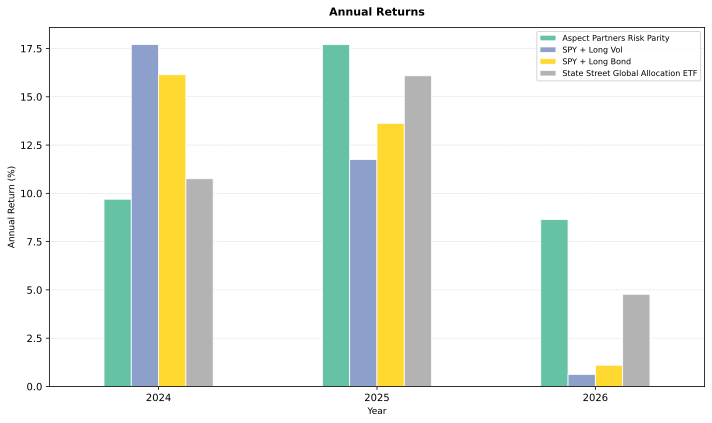

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
n_portfolios = len(df_results_returns.columns)
cmap = plt.get_cmap('Set2', n_portfolios)  
colors = [cmap(i) for i in range(n_portfolios)]
plt.style.use('seaborn-v0_8-colorblind')
ax = df_results_returns.plot.bar(  
        figsize = (10, 6), 
        rot = 0, 
        color = colors, 
        edgecolor = 'white', 
        linewidth = 0.8)
ax.set_title('Annual Returns',
             fontsize = 11, 
             fontweight = 'bold', 
             pad = 12)
ax.grid(axis='y', linestyle='--', 
        linewidth = 0.5, color='lightgrey')
ax.legend(loc = 'upper right', 
          bbox_to_anchor = (1, 1), 
          frameon = True, 
          fontsize = 8)
ax.set_axisbelow(True)
ax.set_xlabel('Year', fontsize = 9)
ax.set_ylabel('Annual Return (%)', fontsize = 9)
plt.tight_layout()
plt.show();


#### **6. Portfolio Income**

All dividends and distributions reinvested.

In [12]:
initial_value = 10000
years = [2024, 2025, 2026]
portfolios = {
    'Aspect Partners Risk Parity': weights_aprp, 
    'SPY + Long Vol': weights_SPY_vol, 
    'SPY + Long Bond': weights_SPY_bon, 
    'State Street Global Allocation ETF': weights_ETF}
# Compute annual income per portfolio (total return * initial value)
# Prices are total-return adjusted: dividends/distributions are already reinvested
income_data = {}
for name, port_returns in zip(portfolio_names, returns_port):
    weights = portfolios[name]
    annual_income = {}
    for year in years:
        if year not in years_all[name]:
            annual_income[year] = 0
            continue
        df_year = years_all[name][year]
        w = pd.Series(weights)
        common = df_year.columns.intersection(w.index)
        daily_port = df_year[common].dot(w[common])
        cumret = (1 + daily_port).prod() - 1
        annual_income[year] = round(cumret*initial_value, 2)
    income_data[name] = annual_income

df_income = pd.DataFrame(income_data, index = years)
#print(df_income)

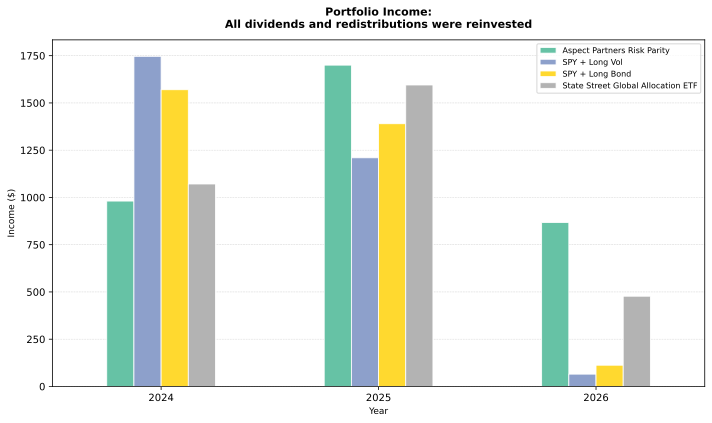

In [13]:
# Plot
n_portfolios = len(df_income.columns)
cmap = plt.get_cmap('Set2', n_portfolios)
colors = [cmap(i) for i in range(n_portfolios)]

ax = df_income.plot.bar(
        figsize = (10, 6),
        rot = 0,
        color = colors,
        edgecolor = 'white',
        linewidth = 0.8)

ax.set_xlabel('Year', fontsize = 9)
ax.set_ylabel('Income ($)', fontsize = 9)
ax.set_title('Portfolio Income:\nAll dividends and redistributions were reinvested',
             fontsize = 11, 
             fontweight = 'bold', 
             pad = 12)
ax.legend(loc = 'upper right', 
          bbox_to_anchor = (1, 1), 
          frameon = True, 
          fontsize = 8)
ax.grid(axis = 'y', 
        linestyle = '--', 
        linewidth = 0.5, 
        color = 'lightgrey')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show();